# 🥇 Gold Bot v2 — Moteur de Backtest Événementiel (Event-Driven)

Réplication fidèle de `bot_headless.py` : moteur hybride **M5 (signaux) / M1 (simulation intra-trade)**.

**Architecture :**
- Indicateurs calculés sur fenêtre glissante M5 (100 bougies)
- Détection de signal → score → filtres horaires
- Simulation des trades sur données M1 pour TP/SL précis
- Breakeven automatique, SL Cap 22 pts, Daily Stop -150 $

**Décalage horaire :** CSV en GMT+3 (Broker) → soustraction de 1h pour passer en GMT+2 (PC/Bot).

In [13]:
# ============================================================
# CELLULE 1 — Imports & Configuration globale
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from datetime import timedelta
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Chemins CSV (adapter si nécessaire) ─────────────────────
PATH_M1 = Path('data/XAUUSD-VIP_M1_6Months.csv')
PATH_M5 = Path('data/XAUUSD-VIP_M5_6Months.csv')

# ── Paramètres de trading (modifiables) ─────────────────────
LOT_SIZE       = 0.03
PNL_PER_POINT  = 3.0      # 0.03 lot × 100 $/point (XAU) = 3 $/point
MAX_RISK_PTS   = 22.0
DAILY_MAX_LOSS = -150.0
SESSION_MID_H  = 12        # Heure PC (GMT+2)
SESSION_END_H  = 15        # Heure PC (GMT+2)
GMT_OFFSET     = -1        # Décalage Broker→PC : GMT+3 → GMT+2
MAX_TRADES_PER_DAY = 60

# ── Modes disponibles ────────────────────────────────────────
MODES_CONFIG = {
    'safe':     {'sl_mult':2.5, 'tp1_mult':1.5, 'tp2_mult':2.5, 'tp3_mult':4.0, 'score_min':60, 'cooldown':300},
    'risque':   {'sl_mult':1.8, 'tp1_mult':1.2, 'tp2_mult':2.0, 'tp3_mult':3.2, 'score_min':45, 'cooldown':180},
    'risque+++':{'sl_mult':1.5, 'tp1_mult':1.0, 'tp2_mult':1.8, 'tp3_mult':2.8, 'score_min':35, 'cooldown':90},
    'optimale':{'sl_mult':1.2,'tp1_mult':1.0, 'tp2_mult':1.8, 'tp3_mult':2.8, 'score_min':35, 'cooldown':90},
}

# ── Paramètre global de mode actif (modifiable pour tests) ──
TRADING_MODE = 'optimale'

print('✅ Imports et configuration OK')
print(f'   Mode : {TRADING_MODE} | Score min : {MODES_CONFIG[TRADING_MODE]["score_min"]} | SL mult : {MODES_CONFIG[TRADING_MODE]["sl_mult"]}')

✅ Imports et configuration OK
   Mode : optimale | Score min : 35 | SL mult : 1.2


In [14]:
# ============================================================
# CELLULE 2 — Chargement & Alignement Temporel
# ============================================================

def load_csv(path: Path, label: str) -> pd.DataFrame:
    """Charge un CSV OHLCV broker, applique le décalage GMT+3 → GMT+2."""
    df = pd.read_csv(path, parse_dates=['Time'])
    df.rename(columns={'TickVolume': 'Volume'}, inplace=True)
    # [FIX TIMEZONE] CSV en heure Broker (GMT+3) → PC Bot (GMT+2) : -1h
    df['Time'] = df['Time'] + pd.Timedelta(hours=GMT_OFFSET)
    df.set_index('Time', inplace=True)
    df.sort_index(inplace=True)
    df[['Open','High','Low','Close','Volume']] = df[['Open','High','Low','Close','Volume']].astype(float)
    print(f'✅ {label} chargé : {len(df):,} bougies | {df.index[0]} → {df.index[-1]}')
    return df

df_m5 = load_csv(PATH_M5, 'M5')
df_m1 = load_csv(PATH_M1, 'M1')

print(f'\nAperçu M5 (5 premières lignes):')
display(df_m5.head())

✅ M5 chargé : 34,822 bougies | 2025-11-10 00:00:00 → 2026-05-08 19:25:00
✅ M1 chargé : 173,813 bougies | 2025-11-10 00:00:00 → 2026-05-08 19:29:00

Aperçu M5 (5 premières lignes):


,Open,High,Low,Close,Volume
Time,,,,,
2025-11-10 00:00:00,4000.52,4010.63,3998.57,4006.41,1891.0
2025-11-10 00:05:00,4006.41,4010.38,4005.32,4009.36,1246.0
2025-11-10 00:10:00,4009.37,4011.58,4008.04,4010.71,1173.0
2025-11-10 00:15:00,4010.57,4011.51,4004.49,4006.44,1746.0
2025-11-10 00:20:00,4006.44,4010.86,4006.44,4010.51,1378.0


In [15]:
# ============================================================
# CELLULE 3 — Fonctions Indicateurs (répliques exactes du bot)
# ============================================================

def compute_vwap(df: pd.DataFrame, window: int = 50) -> pd.Series:
    """VWAP glissant — réplique exacte de bot_headless.compute_vwap."""
    typical = (df['High'] + df['Low'] + df['Close']) / 3
    tp_vol  = typical * df['Volume']
    return tp_vol.rolling(window).sum() / df['Volume'].rolling(window).sum()


def compute_volume_profile(df: pd.DataFrame, bins: int = 20) -> dict:
    """Volume Profile (POC + Value Area 70%) — réplique exacte."""
    price_min = df['Low'].min()
    price_max = df['High'].max()
    if price_max == price_min:
        return {'poc': df['Close'].iloc[-1],
                'value_area_high': price_max,
                'value_area_low':  price_min}
    volumes, edges = np.histogram(df['Close'], bins=bins, weights=df['Volume'])
    poc_idx   = volumes.argmax()
    poc       = (edges[poc_idx] + edges[poc_idx + 1]) / 2
    target    = volumes.sum() * 0.70
    sorted_i  = np.argsort(volumes)[::-1]
    acc, va_i = 0, []
    for idx in sorted_i:
        acc += volumes[idx]; va_i.append(idx)
        if acc >= target: break
    va_high = max((edges[i]+edges[i+1])/2 for i in va_i)
    va_low  = min((edges[i]+edges[i+1])/2 for i in va_i)
    return {'poc': round(poc,2), 'value_area_high': round(va_high,2), 'value_area_low': round(va_low,2)}


def compute_atr(df: pd.DataFrame, window: int = 14) -> float:
    """ATR — réplique exacte."""
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift()).abs(),
        (df['Low']  - df['Close'].shift()).abs(),
    ], axis=1).max(axis=1)
    return round(tr.rolling(window).mean().iloc[-1], 2)


def _detect_candle_pattern(df: pd.DataFrame) -> str:
    """Patterns bougies — réplique exacte."""
    o,h,l,c = df['Open'].iloc[-1], df['High'].iloc[-1], df['Low'].iloc[-1], df['Close'].iloc[-1]
    body   = abs(c-o); candle = h-l
    if candle == 0: return 'Doji'
    ratio      = body/candle
    lower_wick = min(o,c)-l
    upper_wick = h-max(o,c)
    if ratio < 0.1:                                                  return 'Doji'
    if lower_wick > body*2 and upper_wick < body*0.5 and c > o:     return 'Marteau'
    if upper_wick > body*2 and lower_wick < body*0.5 and c < o:     return 'Shooting Star'
    prev_o,prev_c = df['Open'].iloc[-2], df['Close'].iloc[-2]
    if c>o and c>prev_o and o<prev_c and prev_c<prev_o:             return 'Engulfing haussier'
    if c<o and c<prev_o and o>prev_c and prev_c>prev_o:             return 'Engulfing baissier'
    if lower_wick > body*3:                                          return 'Pin Bar haussier'
    if upper_wick > body*3:                                          return 'Pin Bar baissier'
    return 'Neutre'


def compute_indicators(df: pd.DataFrame) -> dict:
    """Calcul complet des indicateurs — réplique exacte de bot_headless.compute_indicators.
    Fenêtre Volume Profile : 100 dernières bougies (tail(100)).
    """
    close = df['Close']; high = df['High']; low = df['Low']; vol = df['Volume']
    price = close.iloc[-1]
    atr   = compute_atr(df)

    vwap_series = compute_vwap(df, window=50)
    vwap        = vwap_series.iloc[-1]
    typical     = (high+low+close)/3
    vwap_std    = (typical - vwap_series).rolling(50).std().iloc[-1]
    if np.isnan(vwap_std) or vwap_std == 0: vwap_std = 1e-9

    vwap_upper1 = round(vwap + 1.0*vwap_std, 2)
    vwap_lower1 = round(vwap - 1.0*vwap_std, 2)
    vwap_upper2 = round(vwap + 2.0*vwap_std, 2)
    vwap_lower2 = round(vwap - 2.0*vwap_std, 2)
    dist_vwap   = round(price - vwap, 2)
    dist_vwap_sd= round(dist_vwap / vwap_std, 2)
    vwap_slope  = round(vwap_series.diff(5).iloc[-1], 2)

    vp      = compute_volume_profile(df.tail(100))
    poc     = vp['poc']
    near_poc= abs(price - poc) < atr * 0.5

    swing_high = round(df.tail(30)['High'].max(), 2)
    swing_low  = round(df.tail(30)['Low'].min(),  2)
    near_swing_support    = abs(price - swing_low)  < atr * 1.0
    near_swing_resistance = abs(price - swing_high) < atr * 1.0

    ema200    = close.ewm(span=200, adjust=False).mean().iloc[-1]
    above_200 = price > ema200
    ema20     = close.ewm(span=20,  adjust=False).mean()
    ema50     = close.ewm(span=50,  adjust=False).mean()
    ema_cross_bull = (ema20.iloc[-1]>ema50.iloc[-1] and ema20.iloc[-2]<=ema50.iloc[-2])
    ema_cross_bear = (ema20.iloc[-1]<ema50.iloc[-1] and ema20.iloc[-2]>=ema50.iloc[-2])

    avg_vol   = vol.rolling(20).mean().iloc[-1]
    vol_ratio = round(vol.iloc[-1]/avg_vol, 2) if avg_vol>0 else 1.0
    vol_spike = vol_ratio > 1.4

    cur_open  = df['Open'].iloc[-1]; cur_close = close.iloc[-1]
    cur_body  = abs(cur_close-cur_open)
    cur_bull  = cur_close > cur_open; cur_bear = cur_close < cur_open
    last10    = close.iloc[-11:-1]
    move10    = last10.iloc[-1]-last10.iloc[0]
    above_50  = price > ema50.iloc[-1]

    bounce_bull = (
        near_swing_support and cur_bull and cur_body > atr*0.5
        and vol_ratio > 1.4 and move10 < -atr*1.5
        and (not above_200 or (above_200 and near_poc))
    )
    bounce_bear = (
        near_swing_resistance and cur_bear and cur_body > atr*0.5
        and vol_ratio > 1.4 and move10 > atr*1.5
    )
    pattern = _detect_candle_pattern(df)

    return {
        'price': round(price,2), 'atr': atr,
        'vwap': round(vwap,2), 'vwap_upper1': vwap_upper1, 'vwap_lower1': vwap_lower1,
        'vwap_upper2': vwap_upper2, 'vwap_lower2': vwap_lower2,
        'dist_vwap_sd': dist_vwap_sd, 'vwap_slope': vwap_slope,
        'poc': poc, 'va_high': vp['value_area_high'], 'va_low': vp['value_area_low'],
        'near_poc': near_poc, 'swing_high': swing_high, 'swing_low': swing_low,
        'near_swing_sup': near_swing_support, 'near_swing_res': near_swing_resistance,
        'ema200': round(ema200,2), 'ema20': round(ema20.iloc[-1],2), 'ema50': round(ema50.iloc[-1],2),
        'above_200': above_200, 'above_50': above_50,
        'ema_cross_bull': ema_cross_bull, 'ema_cross_bear': ema_cross_bear,
        'vol_ratio': vol_ratio, 'vol_spike': vol_spike,
        'bounce_bull': bounce_bull, 'bounce_bear': bounce_bear,
        'move10': round(move10,2), 'pattern': pattern,
    }

print('✅ Fonctions indicateurs définies')

✅ Fonctions indicateurs définies


In [16]:
# ============================================================
# CELLULE 4 — Direction, Score & Niveaux TP/SL
# ============================================================

def determine_direction(ind: dict):
    """Réplique exacte de bot_headless.determine_direction."""
    if abs(ind['vwap_slope']) < ind['atr'] * 0.1:  # [FIX VWAP SLOPE]
        return None, 'vwap_flat'
    dist = ind['dist_vwap_sd']
    if dist > 4.5 or dist < -4.5:                  # [FIX SD CAP]
        return None, 'sd_cap'

    price     = ind['price']
    above_200 = ind['above_200']
    above_50  = ind['above_50']

    if ind['bounce_bull']: return 'BUY',  'bounce_bull'
    if ind['bounce_bear']: return 'SELL', 'bounce_bear'

    vwap_long  = price < ind['vwap_lower1']
    vwap_short = price > ind['vwap_upper1']
    struct_long  = ind['near_swing_sup'] or ind['near_poc']
    struct_short = ind['near_swing_res'] or ind['near_poc']
    vol_ok = ind['vol_ratio'] > 1.0

    if vwap_long  and struct_long  and above_200 and above_50 and (vol_ok or ind['ema_cross_bull']):
        return 'BUY',  'vwap_1sd'
    if vwap_short and struct_short and not above_200 and not above_50 and (vol_ok or ind['ema_cross_bear']):
        return 'SELL', 'vwap_1sd'
    if price < ind['vwap_lower2'] and above_200 and vol_ok:
        return 'BUY',  'vwap_2sd'
    if price > ind['vwap_upper2'] and not above_200 and vol_ok:
        return 'SELL', 'vwap_2sd'
    return None, 'no_setup'


def compute_score(ind: dict, direction: str):
    """Réplique exacte de bot_headless.compute_score."""
    score = 0; reasons = []; is_buy = direction == 'BUY'
    dist_sd = abs(ind['dist_vwap_sd'])
    if   dist_sd >= 2.0: score += 30; reasons.append(f'SD={dist_sd:.1f}>=2.0 (+30)')
    elif dist_sd >= 1.0: score += 18; reasons.append(f'SD={dist_sd:.1f}>=1.0 (+18)')
    elif dist_sd >= 0.5: score +=  8; reasons.append(f'SD={dist_sd:.1f}>=0.5 (+8)')

    if   is_buy  and ind['vwap_slope'] > 0: score += 5; reasons.append('Slope+ (+5)')
    elif not is_buy and ind['vwap_slope'] < 0: score += 5; reasons.append('Slope- (+5)')

    if is_buy:
        if ind['near_swing_sup']: score += 15; reasons.append('SwingSup (+15)')
        if ind['near_poc']:       score += 10; reasons.append('POC (+10)')
        if ind['price'] < ind['va_low']:  score += 10; reasons.append('BelowVAL (+10)')
        if ind['above_200']:      score +=  5; reasons.append('Above200 (+5)')
    else:
        if ind['near_swing_res']: score += 15; reasons.append('SwingRes (+15)')
        if ind['near_poc']:       score += 10; reasons.append('POC (+10)')
        if ind['price'] > ind['va_high']: score += 10; reasons.append('AboveVAH (+10)')
        if not ind['above_200']:  score +=  5; reasons.append('Below200 (+5)')

    vr = ind['vol_ratio']
    if   ind['bounce_bull'] or ind['bounce_bear']: score += 25; reasons.append(f'Bounce (+25)')
    elif vr >= 2.0: score += 20; reasons.append(f'VolSpike x{vr} (+20)')
    elif vr >= 1.4: score += 12; reasons.append(f'VolHigh x{vr} (+12)')
    elif vr >= 1.0: score +=  5; reasons.append(f'VolOK x{vr} (+5)')

    if   is_buy  and ind['ema_cross_bull']: score += 10; reasons.append('GoldenX (+10)')
    elif not is_buy and ind['ema_cross_bear']: score += 10; reasons.append('DeathX (+10)')

    bull_p = {'Marteau','Engulfing haussier','Pin Bar haussier'}
    bear_p = {'Shooting Star','Engulfing baissier','Pin Bar baissier'}
    if   is_buy  and ind['pattern'] in bull_p:  score += 15; reasons.append(f"{ind['pattern']} (+15)")
    elif not is_buy and ind['pattern'] in bear_p: score += 15; reasons.append(f"{ind['pattern']} (+15)")
    elif ind['pattern'] == 'Doji': score += 3; reasons.append('Doji (+3)')

    return min(score, 100), reasons


def calculate_tp_sl(direction: str, entry: float, atr: float,
                    swing_high: float, swing_low: float, mode: str = TRADING_MODE) -> dict:
    """Réplique exacte de bot_headless.calculate_tp_sl avec SL Cap."""
    m = MODES_CONFIG[mode]
    if direction == 'BUY':
        sl_str   = round(swing_low - atr*0.2, 2)
        sl_atr   = round(entry - atr*m['sl_mult'], 2)
        sl       = min(sl_str, sl_atr)
        sl_floor = round(entry - atr*max(m['sl_mult'],1.5), 2)
        sl       = min(sl, sl_floor)
        risk     = abs(entry - sl)
        if risk > MAX_RISK_PTS:         # [FIX SL CAP]
            sl   = round(entry - MAX_RISK_PTS, 2)
            risk = MAX_RISK_PTS
        return {'sl': sl,
                'tp1': round(entry + risk*m['tp1_mult'],2),
                'tp2': round(entry + risk*m['tp2_mult'],2),
                'tp3': round(entry + risk*m['tp3_mult'],2)}
    else:
        sl_str  = round(swing_high + atr*0.2, 2)
        sl_atr  = round(entry + atr*m['sl_mult'], 2)
        sl      = max(sl_str, sl_atr)
        sl_ceil = round(entry + atr*max(m['sl_mult'],1.5), 2)
        sl      = max(sl, sl_ceil)
        risk    = abs(sl - entry)
        if risk > MAX_RISK_PTS:         # [FIX SL CAP]
            sl   = round(entry + MAX_RISK_PTS, 2)
            risk = MAX_RISK_PTS
        return {'sl': sl,
                'tp1': round(entry - risk*m['tp1_mult'],2),
                'tp2': round(entry - risk*m['tp2_mult'],2),
                'tp3': round(entry - risk*m['tp3_mult'],2)}

print('✅ Fonctions signal & niveaux définies')

✅ Fonctions signal & niveaux définies


In [17]:
# ============================================================
# CELLULE 5 (REMPLACEMENT) — Simulateur M1 optimisé
# ============================================================
# Changements vs version originale :
#   1. df_m1.index.searchsorted()  au lieu du masque booléen O(n)
#   2. bars['High'].values / bars['Low'].values  au lieu d'iterrows
#   Logique breakeven et priorité TP/SL : identique à l'original

def simulate_trade_m1(direction: str, entry: float, levels: dict,
                       open_time: pd.Timestamp, df_m1: pd.DataFrame) -> list:
    """
    Simule le parcours de prix en M1 pour un trade ouvert à `open_time`.
    Version optimisée : searchsorted + tableaux numpy (pas d'iterrows).
    Logique métier identique à la version originale.
    """
    sl_orig = levels['sl']
    tp1, tp2, tp3 = levels['tp1'], levels['tp2'], levels['tp3']

    # ── [OPT] Slicing rapide via searchsorted (O(log n) vs O(n)) ──
    start_pos = df_m1.index.searchsorted(open_time)
    bars = df_m1.iloc[start_pos:]

    if bars.empty:
        return []

    positions = [
        {'id': 'P1', 'tp': tp1, 'sl': sl_orig,
         'result': None, 'exit_px': None, 'closed': False},
        {'id': 'P2', 'tp': tp2, 'sl': sl_orig,
         'result': None, 'exit_px': None, 'closed': False},
        {'id': 'P3', 'tp': tp3, 'sl': sl_orig,
         'result': None, 'exit_px': None, 'closed': False},
    ]
    tp1_hit = False
    tp2_hit = False

    # ── [OPT] Extraire les tableaux numpy une seule fois ──────────
    highs  = bars['High'].values
    lows   = bars['Low'].values
    closes = bars['Close'].values

    for k in range(len(highs)):
        if all(p['closed'] for p in positions):
            break

        bar_high = highs[k]
        bar_low  = lows[k]

        for p in positions:
            if p['closed']:
                continue

            sl_cur = p['sl']
            tp_cur = p['tp']

            if direction == 'BUY':
                tp_hit = bar_high >= tp_cur
                sl_hit = bar_low  <= sl_cur
            else:
                tp_hit = bar_low  <= tp_cur
                sl_hit = bar_high >= sl_cur

            # Priorité : si les deux touchés, le plus proche de l'entrée d'abord
            if tp_hit and sl_hit:
                dist_tp = abs(tp_cur - entry)
                dist_sl = abs(sl_cur - entry)
                tp_hit  = dist_tp < dist_sl
                sl_hit  = not tp_hit

            if tp_hit:
                p['closed']  = True
                p['exit_px'] = tp_cur
                pts = (tp_cur - entry) if direction == 'BUY' else (entry - tp_cur)
                p['result'] = p['id'].replace('P', 'TP')
                p['pnl']    = round(pts * PNL_PER_POINT, 2)

                # Breakeven : TP1 touché → SL de P2 et P3 → entry
                if p['id'] == 'P1' and not tp1_hit:
                    tp1_hit = True
                    for other in positions:
                        if not other['closed']:
                            other['sl'] = entry          # [FIX BREAKEVEN]

                # SL de P3 → TP1 après TP2
                if p['id'] == 'P2' and not tp2_hit and tp1_hit:
                    tp2_hit = True
                    for other in positions:
                        if not other['closed']:
                            other['sl'] = tp1

            elif sl_hit:
                p['closed']  = True
                p['exit_px'] = p['sl']
                pts = (entry - p['sl']) if direction == 'BUY' else (p['sl'] - entry)
                if abs(p['sl'] - entry) < 0.01:
                    p['result'] = 'BE'
                    p['pnl']    = 0.0
                else:
                    p['result'] = 'SL'
                    p['pnl']    = round(-pts * PNL_PER_POINT, 2)

    # Positions encore ouvertes → fermées au dernier prix
    last_close = closes[-1]
    for p in positions:
        if not p['closed']:
            pts = (last_close - entry) if direction == 'BUY' else (entry - last_close)
            p['result']  = 'OPEN_END'
            p['exit_px'] = last_close
            p['pnl']     = round(pts * PNL_PER_POINT, 2)
            p['closed']  = True

    return positions

print('✅ simulate_trade_m1 optimisé (searchsorted + numpy)')

✅ simulate_trade_m1 optimisé (searchsorted + numpy)


In [18]:
# ============================================================
# CELLULE 6 — Moteur de Backtest Principal (Event-Driven)
# ============================================================

def run_backtest(df_m5: pd.DataFrame,
                 df_m1: pd.DataFrame,
                 mode: str = TRADING_MODE,
                 score_min_override: float = None,
                 sl_mult_override: float = None) -> pd.DataFrame:
    """
    Moteur événementiel complet.
    Paramètres modifiables pour analyse de sensibilité :
      score_min_override : remplace le score_min du mode
      sl_mult_override   : remplace le sl_mult du mode
    """
    m = MODES_CONFIG[mode].copy()
    if score_min_override is not None: m['score_min'] = score_min_override
    if sl_mult_override   is not None: m['sl_mult']   = sl_mult_override

    trades_log      = []   # Journal complet de tous les trades
    signals_ignored = []   # Signaux filtrés

    # État journalier
    daily_pnl      = 0.0
    trades_today   = 0
    last_sl_time   = pd.Timestamp('1970-01-01')
    last_signal_ts = pd.Timestamp('1970-01-01')
    current_date   = None
    daily_stopped  = False

    # Compteurs pour l'analyse des filtres
    n_vwap_flat    = 0
    n_sd_cap       = 0
    n_no_setup     = 0
    n_score_low    = 0
    n_session_end  = 0
    n_daily_stop   = 0
    n_cooldown     = 0

    WINDOW = 100   # Fenêtre glissante pour les indicateurs

    candle_times = df_m5.index.tolist()

    for i in range(WINDOW, len(df_m5)):
        ts  = candle_times[i]
        day = ts.date()

        # ── Reset quotidien ──────────────────────────────────
        if day != current_date:
            current_date  = day
            daily_pnl     = 0.0
            trades_today  = 0
            daily_stopped = False

        if daily_stopped:
            n_daily_stop += 1; continue

        # ── [FIX DAILY STOP] Coupe-circuit ───────────────────
        if daily_pnl < DAILY_MAX_LOSS:
            daily_stopped = True
            n_daily_stop += 1; continue

        if trades_today >= MAX_TRADES_PER_DAY:
            continue

        # ── [FIX CUTOFF] Filtre horaire ──────────────────────
        h = ts.hour
        if h >= SESSION_END_H:
            n_session_end += 1; continue

        # ── Cooldown inter-signaux ────────────────────────────
        if (ts - last_signal_ts).total_seconds() < m['cooldown']:
            n_cooldown += 1; continue

        # ── Calcul des indicateurs ───────────────────────────
        window_df = df_m5.iloc[i-WINDOW:i+1].copy()

        try:
            ind = compute_indicators(window_df)
        except Exception:
            continue

        # ── Détermination de la direction ────────────────────
        direction, reject_reason = determine_direction(ind)

        if direction is None:
            if   reject_reason == 'vwap_flat': n_vwap_flat += 1
            elif reject_reason == 'sd_cap':    n_sd_cap    += 1
            else:                              n_no_setup  += 1
            signals_ignored.append({'ts':ts,'reason':reject_reason})
            continue

        # ── Score & Threshold ─────────────────────────────────
        score, reasons = compute_score(ind, direction)

        threshold = m['score_min']
        if h >= SESSION_MID_H:                          # [FIX THRESHOLD +10]
            threshold += 10
        if (ts - last_sl_time).total_seconds() < 300:  # [FIX POST-SL +20]
            threshold += 20

        if score < threshold:
            n_score_low += 1
            signals_ignored.append({'ts':ts,'reason':f'score={score}<{threshold}',
                                    'direction':direction,'score':score,'threshold':threshold})
            continue

        # ── Calcul TP/SL ──────────────────────────────────────
        levels = calculate_tp_sl(direction, ind['price'], ind['atr'],
                                  ind['swing_high'], ind['swing_low'], mode=mode)
        # Appliquer sl_mult override si nécessaire
        if sl_mult_override is not None:
            levels = calculate_tp_sl(direction, ind['price'], ind['atr'],
                                      ind['swing_high'], ind['swing_low'],
                                      mode=mode)

        entry = ind['price']

        # ── Simulation M1 ─────────────────────────────────────
        positions = simulate_trade_m1(direction, entry, levels, ts, df_m1)

        if not positions:
            continue

        seq_pnl = sum(p['pnl'] for p in positions)
        daily_pnl    = round(daily_pnl + seq_pnl, 2)
        trades_today += 1
        last_signal_ts = ts

        # Pénalité post-SL : si une position se termine en SL
        if any(p['result'] == 'SL' for p in positions):
            last_sl_time = ts

        # Logging
        for p in positions:
            trades_log.append({
                'open_time':   ts,
                'day':         day,
                'direction':   direction,
                'entry':       entry,
                'atr':         ind['atr'],
                'score':       score,
                'threshold':   threshold,
                'sl':          levels['sl'],
                'tp1':         levels['tp1'],
                'tp2':         levels['tp2'],
                'tp3':         levels['tp3'],
                'position':    p['id'],
                'result':      p['result'],
                'exit_px':     p['exit_px'],
                'pnl':         p['pnl'],
                'daily_pnl':   daily_pnl,
                'hour':        h,
                'vwap_slope':  ind['vwap_slope'],
                'dist_sd':     ind['dist_vwap_sd'],
                'pattern':     ind['pattern'],
                'vol_ratio':   ind['vol_ratio'],
            })

    df_trades = pd.DataFrame(trades_log)
    df_ignored = pd.DataFrame(signals_ignored)

    filter_stats = {
        'vwap_flat':    n_vwap_flat,
        'sd_cap':       n_sd_cap,
        'no_setup':     n_no_setup,
        'score_low':    n_score_low,
        'session_end':  n_session_end,
        'daily_stop':   n_daily_stop,
        'cooldown':     n_cooldown,
    }

    return df_trades, df_ignored, filter_stats


# ── Lancement du backtest ─────────────────────────────────────
print('🚀 Lancement du backtest...')
df_trades, df_ignored, filter_stats = run_backtest(df_m5, df_m1, mode=TRADING_MODE)
print(f'✅ Backtest terminé : {len(df_trades)} lignes de trades ({len(df_trades)//3 if len(df_trades)>0 else 0} séquences)')

🚀 Lancement du backtest...
✅ Backtest terminé : 111 lignes de trades (37 séquences)


In [19]:
# ============================================================
# CELLULE 6b — Pré-calcul des indicateurs (à insérer après Cell 6)
# ============================================================
# Principe : compute_indicators() est coûteux (rolling pandas sur 100
# bougies). Pour 40 combinaisons de paramètres, on évite de le recalculer
# 40× en le calculant UNE SEULE FOIS ici et en réutilisant le résultat.

import time
from collections import OrderedDict

def precompute_all_indicators(df_m5: pd.DataFrame, window: int = 100) -> OrderedDict:
    """
    Pré-calcule et stocke les indicateurs pour chaque bougie M5.
    Appel unique (~même durée qu'un run_backtest normal).
    Résultat réutilisé par run_backtest_fast() sans recomputation.
    """
    t0 = time.time()
    candle_times = df_m5.index.tolist()
    precomp = OrderedDict()
    total = len(df_m5)

    for i in range(window, total):
        ts = candle_times[i]
        window_df = df_m5.iloc[i - window: i + 1]
        try:
            precomp[ts] = compute_indicators(window_df)
        except Exception:
            pass  # Bougie ignorée (données manquantes)

        # Affichage de progression toutes les 5000 itérations
        if (i - window) % 5000 == 0:
            pct     = (i - window) / (total - window) * 100
            elapsed = time.time() - t0
            eta     = (elapsed / max(i - window, 1)) * (total - window - (i - window))
            print(f'  {pct:5.1f}% — {i - window:,}/{total - window:,} bougies '
                  f'| Écoulé : {elapsed:.0f}s | ETA : {eta:.0f}s')

    print(f'\n✅ Pré-calcul terminé : {len(precomp):,} timestamps en {time.time()-t0:.1f}s')
    return precomp


def run_backtest_fast(precomp: OrderedDict,
                      df_m1: pd.DataFrame,
                      mode: str = TRADING_MODE,
                      score_min_override: float = None,
                      sl_mult_override: float = None) -> tuple:
    """
    Moteur de backtest optimisé pour la sensibilité.
    Réutilise les indicateurs pré-calculés (precomp) au lieu de les
    recalculer — logique de trading IDENTIQUE à run_backtest().

    Correction : sl_mult_override modifie temporairement MODES_CONFIG
    pour que calculate_tp_sl() l'applique réellement (le code original
    recalculait les levels sans appliquer l'override).
    """
    m = MODES_CONFIG[mode].copy()
    if score_min_override is not None:
        m['score_min'] = score_min_override

    # Appliquer sl_mult temporairement dans MODES_CONFIG
    # (calculate_tp_sl lit directement MODES_CONFIG[mode])
    original_sl_mult = MODES_CONFIG[mode]['sl_mult']
    if sl_mult_override is not None:
        MODES_CONFIG[mode]['sl_mult'] = sl_mult_override

    trades_log      = []
    signals_ignored = []

    daily_pnl      = 0.0
    trades_today   = 0
    last_sl_time   = pd.Timestamp('1970-01-01')
    last_signal_ts = pd.Timestamp('1970-01-01')
    current_date   = None
    daily_stopped  = False

    n_vwap_flat = n_sd_cap = n_no_setup = n_score_low = 0
    n_session_end = n_daily_stop = n_cooldown = 0

    try:
        for ts, ind in precomp.items():
            day = ts.date()

            # ── Reset quotidien ────────────────────────────────────
            if day != current_date:
                current_date  = day
                daily_pnl     = 0.0
                trades_today  = 0
                daily_stopped = False

            if daily_stopped:
                n_daily_stop += 1
                continue

            # ── [FIX DAILY STOP] Coupe-circuit ────────────────────
            if daily_pnl < DAILY_MAX_LOSS:
                daily_stopped = True
                n_daily_stop += 1
                continue

            if trades_today >= MAX_TRADES_PER_DAY:
                continue

            # ── [FIX CUTOFF] Filtre horaire ────────────────────────
            h = ts.hour
            if h >= SESSION_END_H:
                n_session_end += 1
                continue

            # ── Cooldown inter-signaux ─────────────────────────────
            if (ts - last_signal_ts).total_seconds() < m['cooldown']:
                n_cooldown += 1
                continue

            # ── Direction (utilise indicateurs pré-calculés) ───────
            direction, reject_reason = determine_direction(ind)
            if direction is None:
                if   reject_reason == 'vwap_flat': n_vwap_flat += 1
                elif reject_reason == 'sd_cap':    n_sd_cap    += 1
                else:                              n_no_setup  += 1
                signals_ignored.append({'ts': ts, 'reason': reject_reason})
                continue

            # ── Score & Threshold ──────────────────────────────────
            score, _ = compute_score(ind, direction)
            threshold = m['score_min']
            if h >= SESSION_MID_H:                                   # [FIX THRESHOLD +10]
                threshold += 10
            if (ts - last_sl_time).total_seconds() < 300:           # [FIX POST-SL +20]
                threshold += 20

            if score < threshold:
                n_score_low += 1
                signals_ignored.append({
                    'ts': ts, 'reason': f'score={score}<{threshold}',
                    'direction': direction, 'score': score, 'threshold': threshold,
                })
                continue

            # ── Calcul TP/SL (MODES_CONFIG déjà mis à jour si override) ──
            levels = calculate_tp_sl(
                direction, ind['price'], ind['atr'],
                ind['swing_high'], ind['swing_low'], mode=mode,
            )

            entry = ind['price']

            # ── Simulation M1 ──────────────────────────────────────
            positions = simulate_trade_m1(direction, entry, levels, ts, df_m1)
            if not positions:
                continue

            seq_pnl    = sum(p['pnl'] for p in positions)
            daily_pnl  = round(daily_pnl + seq_pnl, 2)
            trades_today  += 1
            last_signal_ts = ts

            if any(p['result'] == 'SL' for p in positions):
                last_sl_time = ts

            for p in positions:
                trades_log.append({
                    'open_time':  ts,
                    'day':        day,
                    'direction':  direction,
                    'entry':      entry,
                    'atr':        ind['atr'],
                    'score':      score,
                    'threshold':  threshold,
                    'sl':         levels['sl'],
                    'tp1':        levels['tp1'],
                    'tp2':        levels['tp2'],
                    'tp3':        levels['tp3'],
                    'position':   p['id'],
                    'result':     p['result'],
                    'exit_px':    p['exit_px'],
                    'pnl':        p['pnl'],
                    'daily_pnl':  daily_pnl,
                    'hour':       h,
                    'vwap_slope': ind['vwap_slope'],
                    'dist_sd':    ind['dist_vwap_sd'],
                    'pattern':    ind['pattern'],
                    'vol_ratio':  ind['vol_ratio'],
                })

    finally:
        # Restaurer sl_mult original dans MODES_CONFIG dans tous les cas
        if sl_mult_override is not None:
            MODES_CONFIG[mode]['sl_mult'] = original_sl_mult

    df_trades_out  = pd.DataFrame(trades_log)
    df_ignored_out = pd.DataFrame(signals_ignored)
    filter_stats = {
        'vwap_flat':   n_vwap_flat,
        'sd_cap':      n_sd_cap,
        'no_setup':    n_no_setup,
        'score_low':   n_score_low,
        'session_end': n_session_end,
        'daily_stop':  n_daily_stop,
        'cooldown':    n_cooldown,
    }
    return df_trades_out, df_ignored_out, filter_stats


# ── Lancer le pré-calcul (une seule fois, même durée qu'un run normal) ──
print('⏳ Pré-calcul des indicateurs en cours (à faire UNE SEULE FOIS)...')
precomp_indicators = precompute_all_indicators(df_m5)
print('✅ Indicateurs pré-calculés — prêt pour la sensibilité rapide.')

⏳ Pré-calcul des indicateurs en cours (à faire UNE SEULE FOIS)...
    0.0% — 0/34,722 bougies | Écoulé : 0s | ETA : 1088s
   14.4% — 5,000/34,722 bougies | Écoulé : 25s | ETA : 150s
   28.8% — 10,000/34,722 bougies | Écoulé : 49s | ETA : 122s
   43.2% — 15,000/34,722 bougies | Écoulé : 77s | ETA : 101s
   57.6% — 20,000/34,722 bougies | Écoulé : 101s | ETA : 74s
   72.0% — 25,000/34,722 bougies | Écoulé : 124s | ETA : 48s
   86.4% — 30,000/34,722 bougies | Écoulé : 147s | ETA : 23s

✅ Pré-calcul terminé : 34,722 timestamps en 169.0s
✅ Indicateurs pré-calculés — prêt pour la sensibilité rapide.


In [20]:
# ============================================================
# CELLULE 7 — Statistiques Détaillées
# ============================================================

def compute_stats(df_trades: pd.DataFrame, filter_stats: dict) -> dict:
    if df_trades.empty:
        print('⚠️  Aucun trade dans le backtest.')
        return {}

    # ── Séquences (groupées par open_time + direction) ────────
    seq = df_trades.groupby(['open_time','direction'])['pnl'].sum().reset_index()
    seq.columns = ['open_time','direction','seq_pnl']

    net_profit   = round(df_trades['pnl'].sum(), 2)
    gross_win    = df_trades[df_trades['pnl']>0]['pnl'].sum()
    gross_loss   = abs(df_trades[df_trades['pnl']<0]['pnl'].sum())
    profit_factor= round(gross_win/gross_loss, 2) if gross_loss>0 else float('inf')

    n_seq        = len(seq)
    n_win_seq    = (seq['seq_pnl']>0).sum()
    winrate_seq  = round(n_win_seq/n_seq*100, 1) if n_seq>0 else 0

    # ── Winrate par palier ────────────────────────────────────
    for tp in ['TP1','TP2','TP3','SL','BE']:
        n  = (df_trades['result']==tp).sum()
        pn = df_trades[df_trades['result']==tp]['pnl'].sum()
        print(f'  {tp:6s} : {n:4d} fois | PnL cumulé : {pn:+.2f} $')

    # ── Drawdown maximum ──────────────────────────────────────
    equity       = df_trades.groupby('open_time')['pnl'].sum().cumsum()
    running_max  = equity.cummax()
    drawdown     = equity - running_max
    max_drawdown = round(drawdown.min(), 2)

    print('\n' + '═'*55)
    print(f'  MODE             : {TRADING_MODE.upper()}')
    print(f'  Période          : {df_trades["open_time"].min().date()} → {df_trades["open_time"].max().date()}')
    print(f'  Nb séquences     : {n_seq}')
    print(f'  Net Profit       : {net_profit:+.2f} $')
    print(f'  Profit Factor    : {profit_factor}')
    print(f'  Max Drawdown     : {max_drawdown:.2f} $')
    print(f'  Winrate (séq.)   : {winrate_seq} %')
    print(f'  Meilleure séq.   : {seq["seq_pnl"].max():+.2f} $')
    print(f'  Pire séq.        : {seq["seq_pnl"].min():+.2f} $')
    print('─'*55)
    print('  Filtres :')
    for k,v in filter_stats.items():
        print(f'    {k:<15} : {v:,}')
    print('═'*55)

    return {
        'net_profit': net_profit, 'profit_factor': profit_factor,
        'max_drawdown': max_drawdown, 'winrate_seq': winrate_seq,
        'n_seq': n_seq, 'equity': equity,
    }

print('\n=== RÉSULTATS DU BACKTEST ===')
print('Winrate par palier :')
stats = compute_stats(df_trades, filter_stats)


=== RÉSULTATS DU BACKTEST ===
Winrate par palier :
  TP1    :   26 fois | PnL cumulé : +650.91 $
  TP2    :   14 fois | PnL cumulé : +629.13 $
  TP3    :    6 fois | PnL cumulé : +492.42 $
  SL     :   41 fois | PnL cumulé : -707.37 $
  BE     :   24 fois | PnL cumulé : +0.00 $

═══════════════════════════════════════════════════════
  MODE             : OPTIMALE
  Période          : 2025-11-19 → 2026-05-06
  Nb séquences     : 37
  Net Profit       : +1065.09 $
  Profit Factor    : 2.21
  Max Drawdown     : -347.58 $
  Winrate (séq.)   : 70.3 %
  Meilleure séq.   : +369.60 $
  Pire séq.        : -145.80 $
───────────────────────────────────────────────────────
  Filtres :
    vwap_flat       : 3,669
    sd_cap          : 269
    no_setup        : 18,603
    score_low       : 0
    session_end     : 11,898
    daily_stop      : 246
    cooldown        : 0
═══════════════════════════════════════════════════════


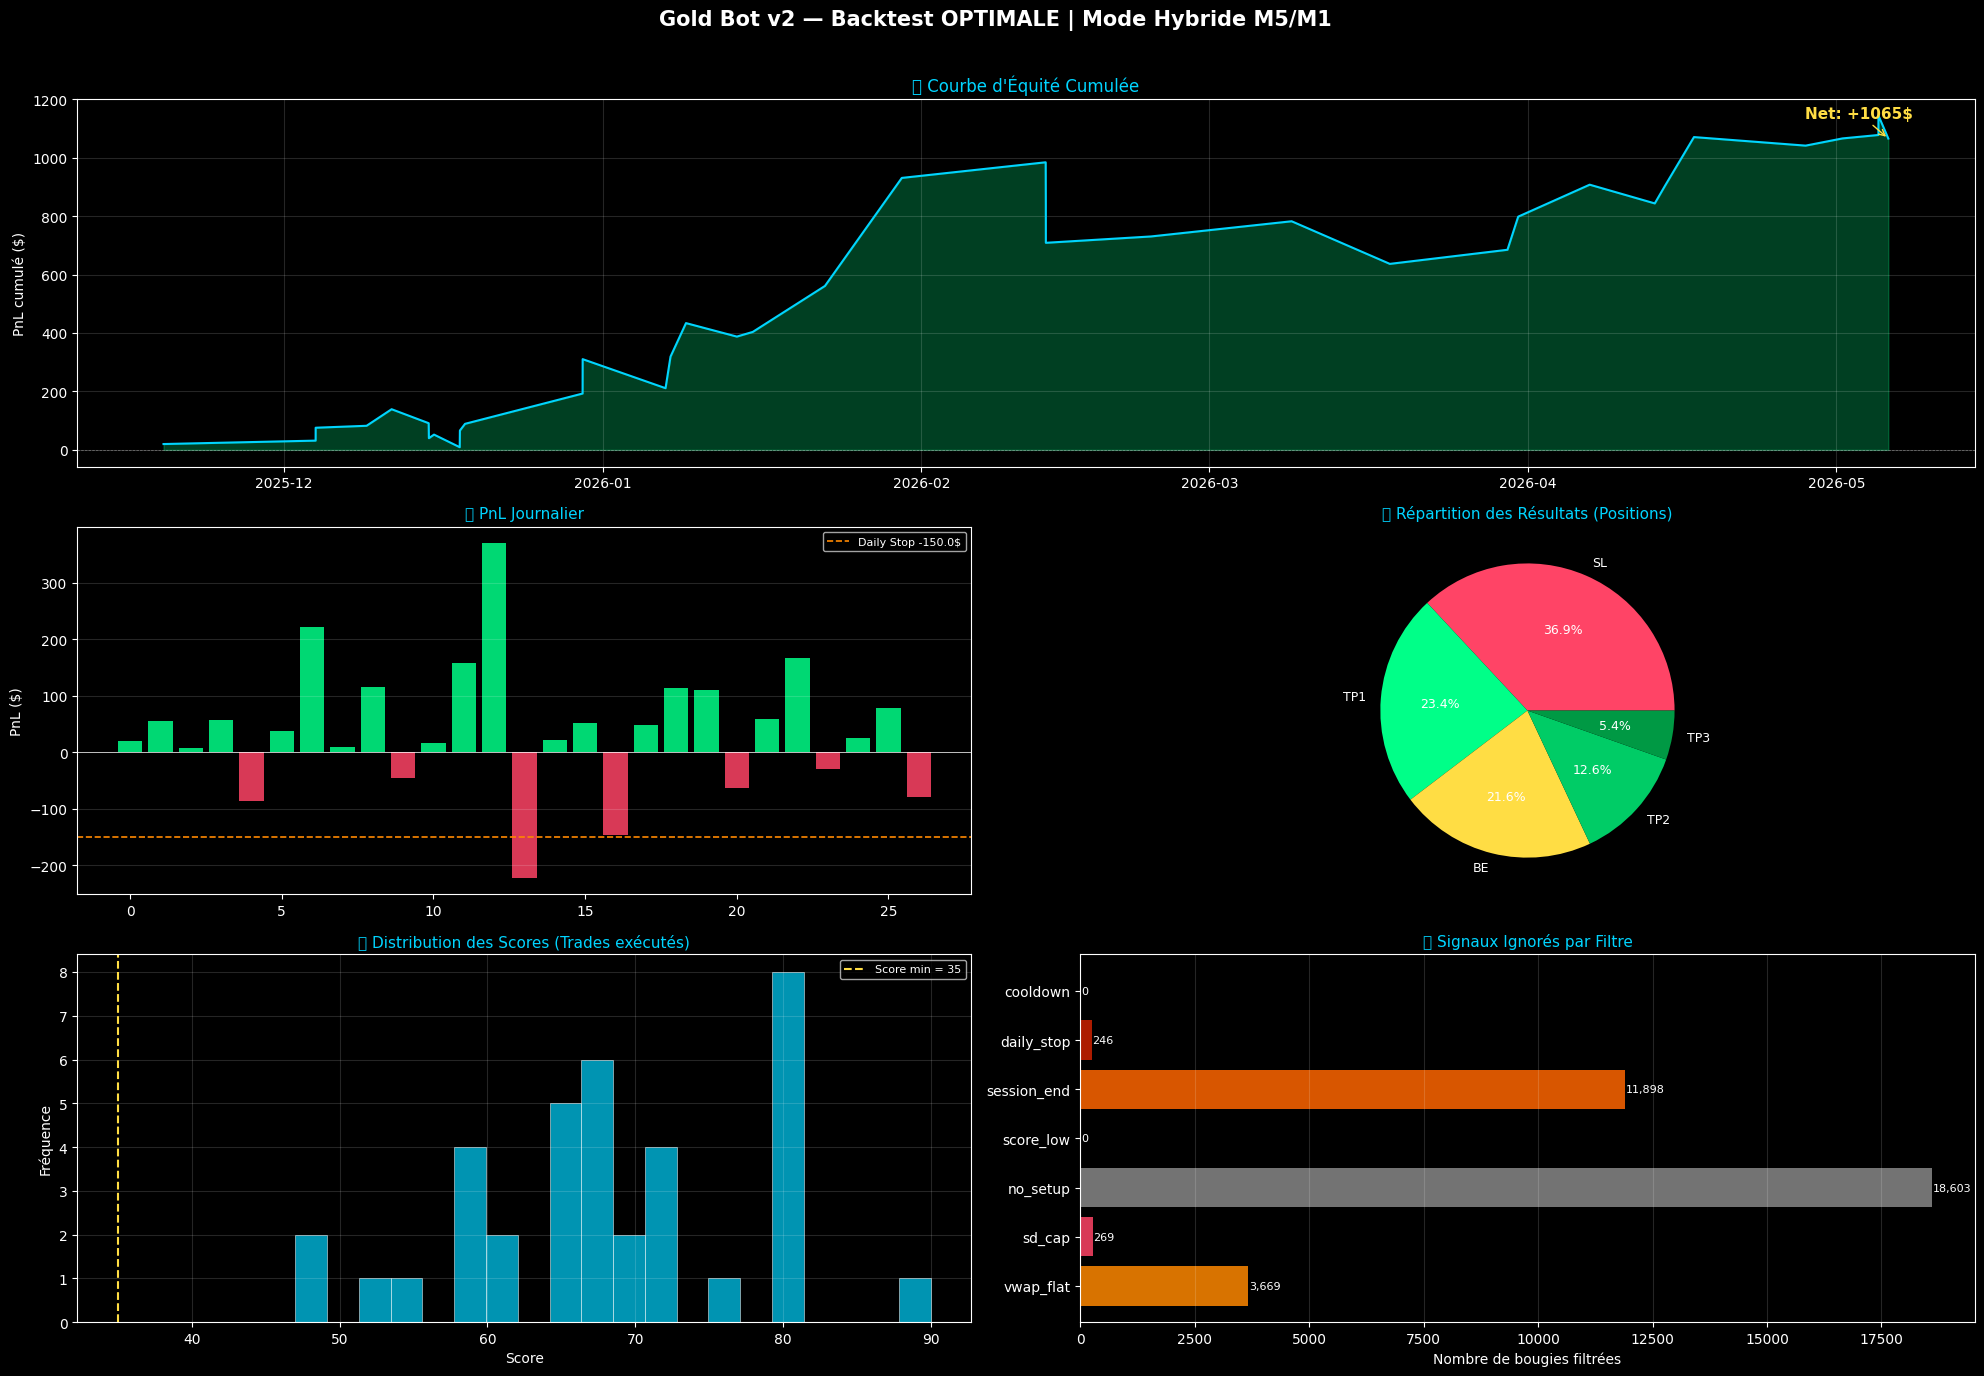

✅ Graphique sauvegardé → backtest_results.png


In [21]:
# ============================================================
# CELLULE 8 — Graphiques
# ============================================================

if df_trades.empty:
    print('⚠️  Aucun trade à afficher.')
else:
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'Gold Bot v2 — Backtest {TRADING_MODE.upper()} | Mode Hybride M5/M1',
                 fontsize=15, fontweight='bold', color='white', y=0.98)

    # ── (1) Equity Curve ──────────────────────────────────────
    ax1 = fig.add_subplot(3, 2, (1, 2))
    equity = stats['equity']
    colors_eq = ['#00ff88' if v >= 0 else '#ff4466' for v in equity.values]
    ax1.fill_between(equity.index, equity.values, alpha=0.25,
                     color='#00ff88' if equity.iloc[-1]>=0 else '#ff4466')
    ax1.plot(equity.index, equity.values, linewidth=1.5, color='#00d4ff', label='Equity')
    ax1.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
    ax1.set_title('📈 Courbe d\'Équité Cumulée', fontsize=12, color='#00d4ff')
    ax1.set_ylabel('PnL cumulé ($)', color='white')
    ax1.tick_params(colors='white'); ax1.grid(alpha=0.15)
    # Annotation final
    ax1.annotate(f"Net: {equity.iloc[-1]:+.0f}$",
                 xy=(equity.index[-1], equity.iloc[-1]),
                 xytext=(-60, 15), textcoords='offset points',
                 color='#ffdd44', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#ffdd44'))

    # ── (2) PnL journalier en barres ──────────────────────────
    ax2 = fig.add_subplot(3, 2, 3)
    daily = df_trades.groupby('day')['pnl'].sum()
    bar_colors = ['#00ff88' if v>=0 else '#ff4466' for v in daily.values]
    ax2.bar(range(len(daily)), daily.values, color=bar_colors, alpha=0.85)
    ax2.axhline(0, color='white', linewidth=0.5)
    ax2.axhline(DAILY_MAX_LOSS, color='#ff8800', linewidth=1.2, linestyle='--', label=f'Daily Stop {DAILY_MAX_LOSS}$')
    ax2.set_title('📅 PnL Journalier', fontsize=11, color='#00d4ff')
    ax2.set_ylabel('PnL ($)', color='white')
    ax2.tick_params(colors='white'); ax2.grid(alpha=0.15, axis='y')
    ax2.legend(fontsize=8)

    # ── (3) Répartition des résultats ────────────────────────
    ax3 = fig.add_subplot(3, 2, 4)
    result_counts = df_trades['result'].value_counts()
    palette = {'TP1':'#00ff88','TP2':'#00cc66','TP3':'#009944',
               'SL':'#ff4466','BE':'#ffdd44','OPEN_END':'#888888'}
    colors_pie = [palette.get(r,'#aaaaaa') for r in result_counts.index]
    wedges, texts, autotexts = ax3.pie(
        result_counts.values, labels=result_counts.index,
        autopct='%1.1f%%', colors=colors_pie,
        textprops={'color':'white','fontsize':9})
    ax3.set_title('🎯 Répartition des Résultats (Positions)', fontsize=11, color='#00d4ff')

    # ── (4) Distribution des scores ──────────────────────────
    ax4 = fig.add_subplot(3, 2, 5)
    scores_traded = df_trades.groupby('open_time')['score'].first()
    ax4.hist(scores_traded.values, bins=20, color='#00d4ff', alpha=0.7, edgecolor='white', linewidth=0.5)
    ax4.axvline(MODES_CONFIG[TRADING_MODE]['score_min'], color='#ffdd44',
                linewidth=1.5, linestyle='--', label=f'Score min = {MODES_CONFIG[TRADING_MODE]["score_min"]}')
    ax4.set_title('📊 Distribution des Scores (Trades exécutés)', fontsize=11, color='#00d4ff')
    ax4.set_xlabel('Score', color='white')
    ax4.set_ylabel('Fréquence', color='white')
    ax4.tick_params(colors='white'); ax4.grid(alpha=0.15)
    ax4.legend(fontsize=8)

    # ── (5) Impact des filtres ────────────────────────────────
    ax5 = fig.add_subplot(3, 2, 6)
    labels_f = list(filter_stats.keys())
    values_f = list(filter_stats.values())
    colors_f = ['#ff8800','#ff4466','#888888','#dd4400','#ff6600','#cc2200','#996600']
    bars = ax5.barh(labels_f, values_f, color=colors_f[:len(labels_f)], alpha=0.85)
    ax5.set_title('🚦 Signaux Ignorés par Filtre', fontsize=11, color='#00d4ff')
    ax5.set_xlabel('Nombre de bougies filtrées', color='white')
    ax5.tick_params(colors='white'); ax5.grid(alpha=0.15, axis='x')
    for bar, val in zip(bars, values_f):
        ax5.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
                 f'{val:,}', va='center', color='white', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight',
                facecolor='#0d0d0d', edgecolor='none')
    plt.show()
    print('✅ Graphique sauvegardé → backtest_results.png')

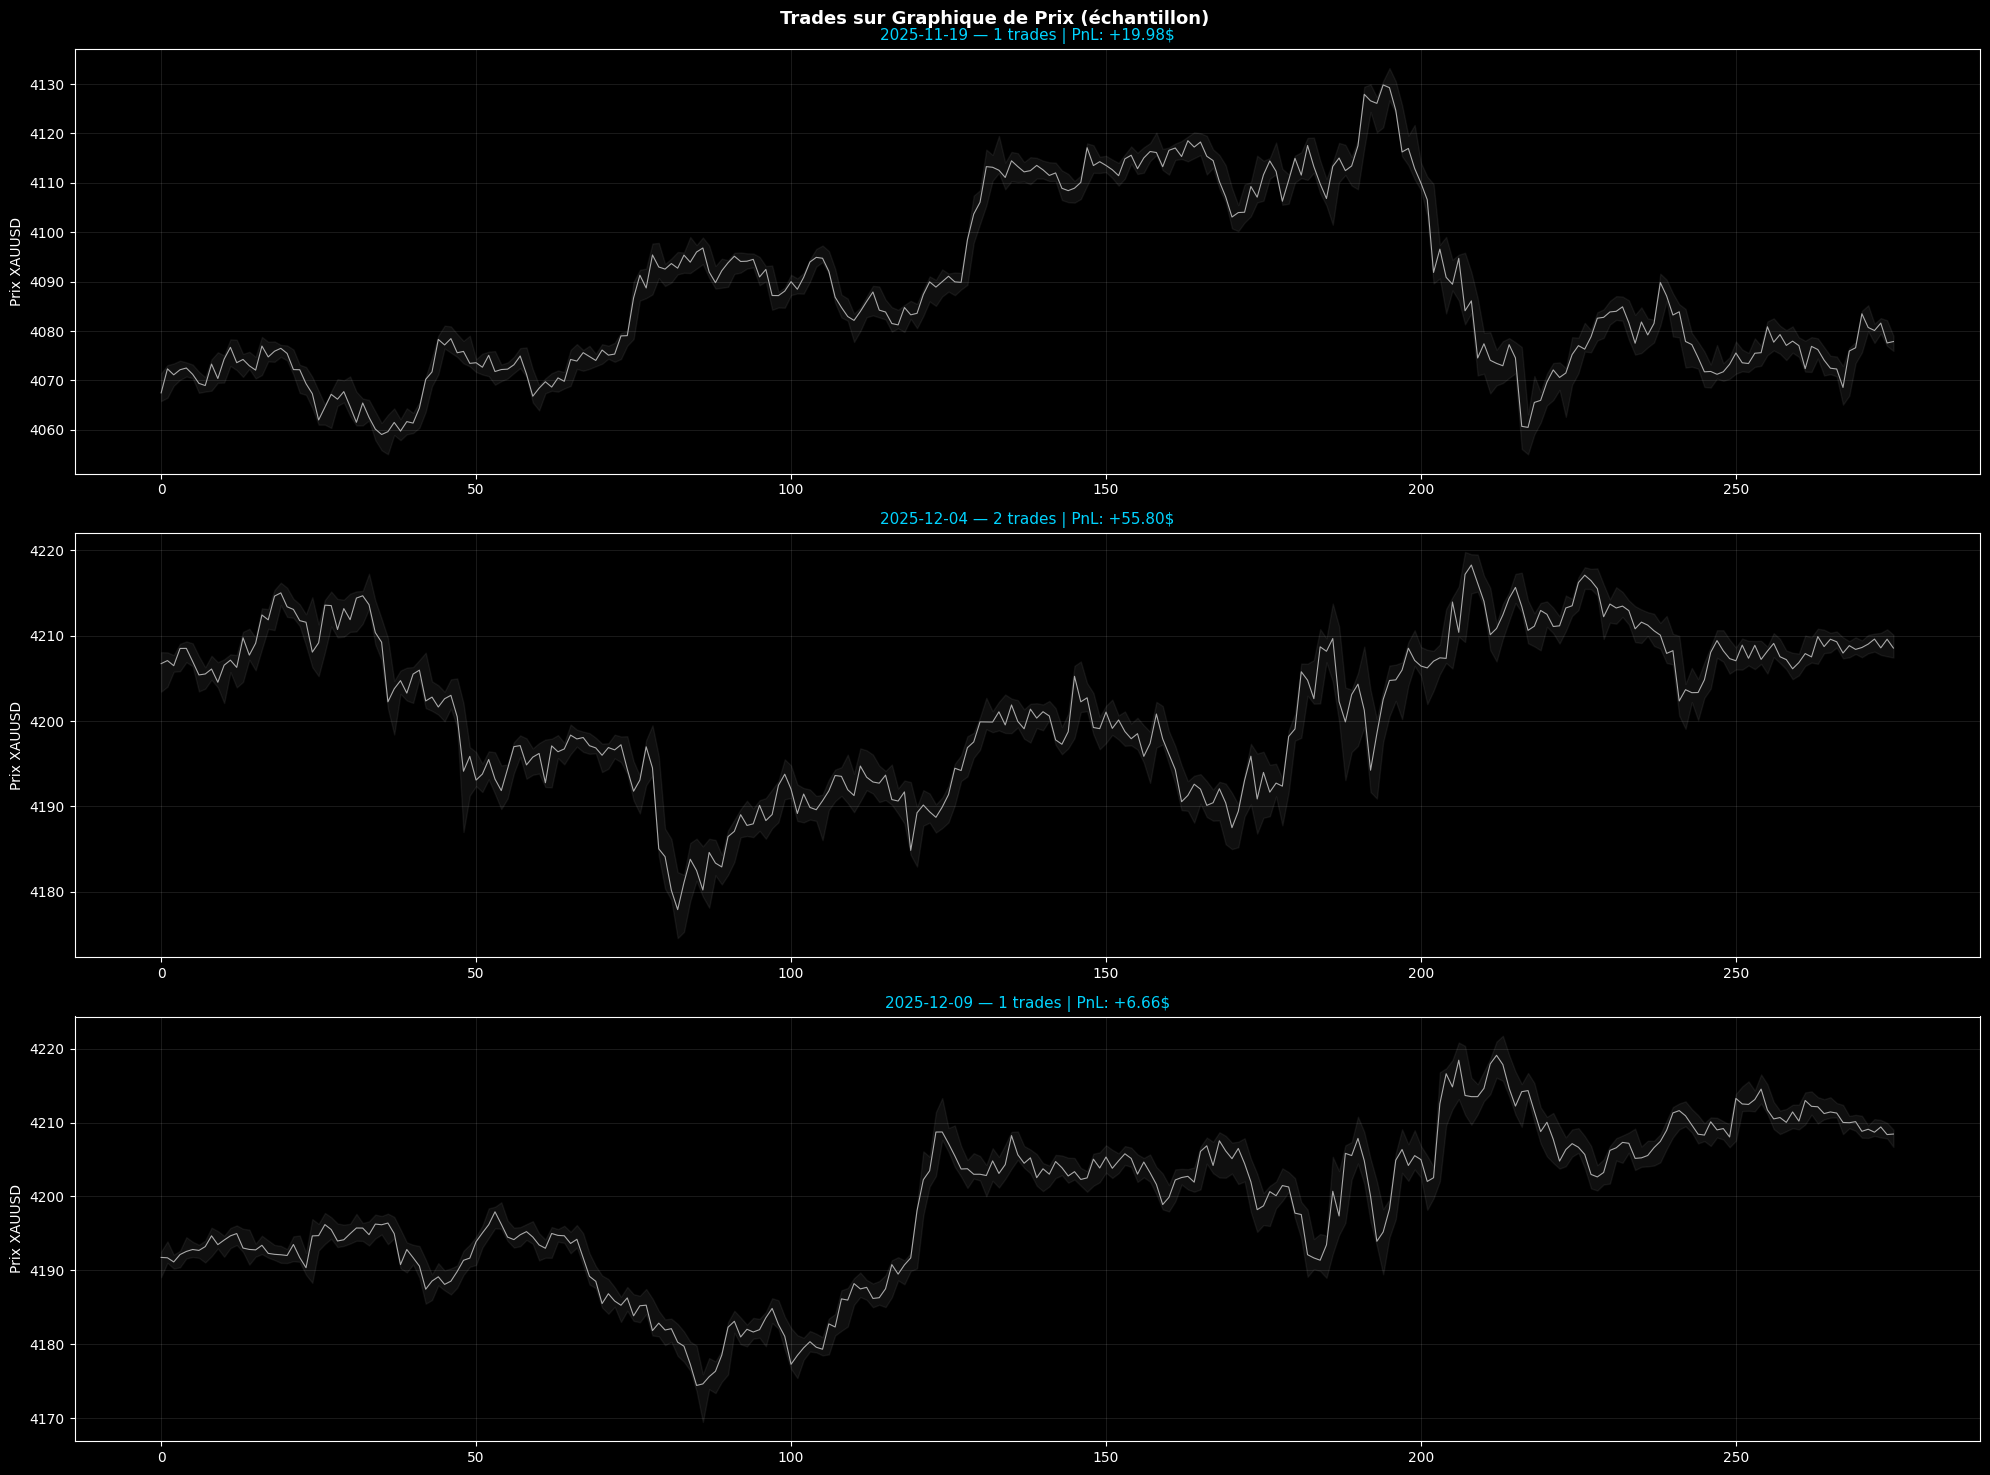

✅ Graphique prix sauvegardé → backtest_price_chart.png


In [22]:
# ============================================================
# CELLULE 9 — Graphique de Prix avec Trades (échantillonnage)
# ============================================================

def plot_trades_on_price(df_m5: pd.DataFrame, df_trades: pd.DataFrame,
                          n_days: int = 3):
    """Affiche les trades sur le graphique de prix pour les N premiers jours tradés."""
    if df_trades.empty:
        print('⚠️  Aucun trade à afficher.'); return

    traded_days = sorted(df_trades['day'].unique())[:n_days]
    if not traded_days:
        print('⚠️  Aucun jour tradé.'); return

    fig, axes = plt.subplots(n_days, 1, figsize=(20, 5*n_days))
    if n_days == 1: axes = [axes]

    for ax, day in zip(axes, traded_days):
        # Données M5 du jour
        day_m5 = df_m5[df_m5.index.date == day]
        if day_m5.empty: continue

        xs = range(len(day_m5))
        ax.fill_between(xs,
                        day_m5['Low'].values - 0.5,
                        day_m5['High'].values + 0.5,
                        alpha=0.12, color='gray')
        ax.plot(xs, day_m5['Close'].values, color='#aaaaaa', linewidth=0.8, label='Close M5')

        # Trades du jour
        day_trades = df_trades[df_trades['day'] == day]

        for _, seq in day_trades.groupby('open_time'):
            row = seq.iloc[0]
            # Position sur l'axe X
            try:
                xi = day_m5.index.get_loc(row['open_time'], method='nearest')
            except Exception:
                continue

            color  = '#00ff88' if row['direction']=='BUY' else '#ff4466'
            marker = '^' if row['direction']=='BUY' else 'v'
            ax.scatter(xi, row['entry'], marker=marker, color=color, s=100, zorder=5)

            # Niveaux
            for lvl, lbl, lc in [
                (row['sl'],  'SL',  '#ff4466'),
                (row['tp1'], 'TP1', '#00ff88'),
                (row['tp2'], 'TP2', '#00cc66'),
                (row['tp3'], 'TP3', '#009944'),
            ]:
                ax.axhline(lvl, color=lc, linewidth=0.6, linestyle=':', alpha=0.5)

            # PnL total
            total_pnl = seq['pnl'].sum()
            ax.annotate(f"{total_pnl:+.1f}$",
                        (xi, row['entry']),
                        textcoords='offset points', xytext=(5, 8 if row['direction']=='BUY' else -14),
                        color='#ffdd44', fontsize=7, fontweight='bold')

        ax.set_title(f'{day} — {len(day_trades)//3} trades | PnL: {day_trades["pnl"].sum():+.2f}$',
                     fontsize=11, color='#00d4ff')
        ax.set_ylabel('Prix XAUUSD', color='white')
        ax.tick_params(colors='white')
        ax.grid(alpha=0.10)

    fig.suptitle('Trades sur Graphique de Prix (échantillon)', fontsize=13,
                 fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig('backtest_price_chart.png', dpi=130, bbox_inches='tight',
                facecolor='#0d0d0d', edgecolor='none')
    plt.show()
    print('✅ Graphique prix sauvegardé → backtest_price_chart.png')

plot_trades_on_price(df_m5, df_trades, n_days=3)

🔬 Analyse de sensibilité rapide en cours...

✅ Sensibilité terminée en 8.2s (40 combinaisons)


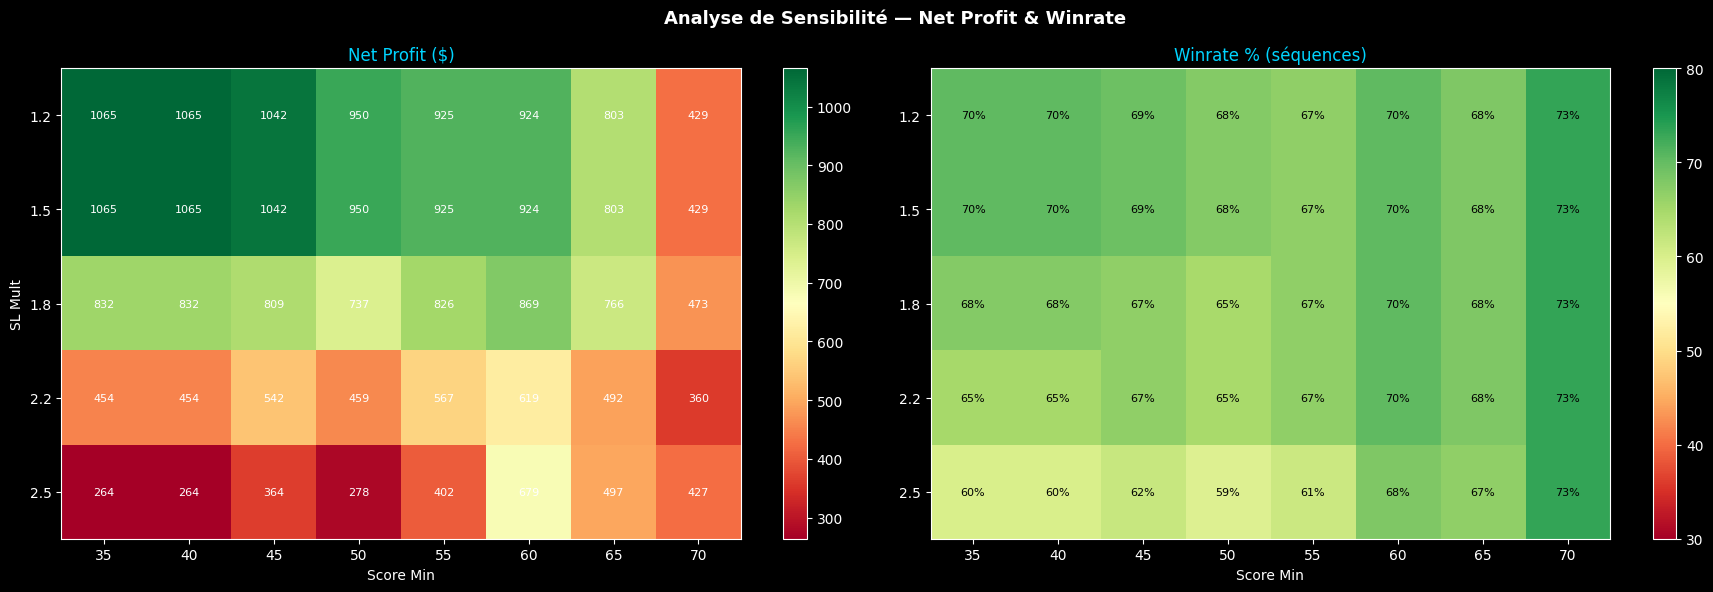

✅ Analyse de sensibilité terminée → sensitivity_analysis.png

🏆 Meilleure combinaison : score_min=35.0 | sl_mult=1.2 → Net: +1065.09$ | WR: 70.3%


In [23]:
# ============================================================
# CELLULE 10 (REMPLACEMENT) — Analyse de Sensibilité RAPIDE
# ============================================================
# Utilise precomp_indicators + run_backtest_fast.
# Les 40 combinaisons ne recalculent plus les indicateurs.

print('🔬 Analyse de sensibilité rapide en cours...\n')
t_sens = time.time()

score_range = [35, 40, 45, 50, 55, 60, 65, 70]
sl_range    = [1.2, 1.5, 1.8, 2.2, 2.5]

results_matrix = []

for sm in score_range:
    for slm in sl_range:
        try:
            dt, _, fs = run_backtest_fast(
                precomp_indicators, df_m1,
                mode=TRADING_MODE,
                score_min_override=sm,
                sl_mult_override=slm,
            )
            if dt.empty:
                results_matrix.append({
                    'score_min': sm, 'sl_mult': slm,
                    'net_profit': 0, 'n_seq': 0, 'winrate': 0, 'pf': 0,
                })
                continue

            seq = dt.groupby('open_time')['pnl'].sum()
            net  = round(seq.sum(), 2)
            n_seq = len(seq)
            wr   = round((seq > 0).sum() / n_seq * 100, 1) if n_seq > 0 else 0
            gl   = abs(dt[dt['pnl'] < 0]['pnl'].sum())
            gw   = dt[dt['pnl'] > 0]['pnl'].sum()
            pf   = round(gw / gl, 2) if gl > 0 else 999

            results_matrix.append({
                'score_min': sm, 'sl_mult': slm,
                'net_profit': net, 'n_seq': n_seq, 'winrate': wr, 'pf': pf,
            })

        except Exception as e:
            results_matrix.append({
                'score_min': sm, 'sl_mult': slm,
                'net_profit': 0, 'n_seq': 0, 'winrate': 0, 'pf': 0,
            })

print(f'✅ Sensibilité terminée en {time.time()-t_sens:.1f}s '
      f'({len(score_range)*len(sl_range)} combinaisons)')

df_sens = pd.DataFrame(results_matrix)

# ── Heatmap Net Profit & Winrate (identique à l'original) ────
pivot    = df_sens.pivot(index='sl_mult', columns='score_min', values='net_profit')
pivot_wr = df_sens.pivot(index='sl_mult', columns='score_min', values='winrate')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Analyse de Sensibilité — Net Profit & Winrate',
             fontsize=13, fontweight='bold', color='white')

im1 = axes[0].imshow(pivot.values, aspect='auto', cmap='RdYlGn')
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns, color='white')
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels(pivot.index, color='white')
axes[0].set_xlabel('Score Min', color='white')
axes[0].set_ylabel('SL Mult', color='white')
axes[0].set_title('Net Profit ($)', color='#00d4ff')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(j, i, f"{pivot.values[i,j]:.0f}",
                     ha='center', va='center', fontsize=8,
                     color='black' if abs(pivot.values[i,j]) < 200 else 'white')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_wr.values, aspect='auto', cmap='RdYlGn', vmin=30, vmax=80)
axes[1].set_xticks(range(len(pivot_wr.columns)))
axes[1].set_xticklabels(pivot_wr.columns, color='white')
axes[1].set_yticks(range(len(pivot_wr.index)))
axes[1].set_yticklabels(pivot_wr.index, color='white')
axes[1].set_xlabel('Score Min', color='white')
axes[1].set_title('Winrate % (séquences)', color='#00d4ff')
for i in range(len(pivot_wr.index)):
    for j in range(len(pivot_wr.columns)):
        axes[1].text(j, i, f"{pivot_wr.values[i,j]:.0f}%",
                     ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=130, bbox_inches='tight',
            facecolor='#0d0d0d', edgecolor='none')
plt.show()
print('✅ Analyse de sensibilité terminée → sensitivity_analysis.png')

# Meilleure combinaison
best = df_sens.loc[df_sens['net_profit'].idxmax()]
print(f'\n🏆 Meilleure combinaison : score_min={best["score_min"]} | '
      f'sl_mult={best["sl_mult"]} → Net: {best["net_profit"]:+.2f}$ | WR: {best["winrate"]}%')


In [24]:
# ============================================================
# CELLULE 11 — Analyse Détaillée des Filtres & Statistiques Avancées
# ============================================================

if not df_trades.empty:
    print('=== ANALYSE DES FILTRES HORAIRES ===')
    print('\nSignaux ignorés par filtre :')
    total_ignored = sum(filter_stats.values())
    for k, v in filter_stats.items():
        pct = v/total_ignored*100 if total_ignored>0 else 0
        bar = '█' * int(pct/2)
        print(f'  {k:<15} : {v:6,}  ({pct:4.1f}%) {bar}')

    print(f'\n  Total ignorés : {total_ignored:,}')
    print(f'  Total exécutés: {len(df_trades)//3}')

    print('\n=== STATS PAR HEURE D\'OUVERTURE ===')
    hourly = df_trades.groupby('hour').agg(
        n_trades=('pnl','count'),
        total_pnl=('pnl','sum'),
        avg_pnl=('pnl','mean'),
    ).round(2)
    hourly['n_seq'] = hourly['n_trades']//3
    display(hourly)

    print('\n=== STATS PAR DIRECTION ===')
    dir_stats = df_trades.groupby('direction').agg(
        n_pos=('pnl','count'),
        total_pnl=('pnl','sum'),
        win_rate=('pnl', lambda x: (x>0).mean()*100),
    ).round(2)
    display(dir_stats)

    print('\n=== TOP 5 MEILLEURES SÉQUENCES ===')
    seq_pnl = df_trades.groupby(['open_time','direction']).agg(
        total_pnl=('pnl','sum'), entry=('entry','first'), score=('score','first')
    ).reset_index().sort_values('total_pnl', ascending=False)
    display(seq_pnl.head())

    print('\n=== TOP 5 PIRES SÉQUENCES ===')
    display(seq_pnl.tail())

    print('\n=== IMPACT SESSION_MID (12h) ===')
    before_mid = df_trades[df_trades['hour'] < SESSION_MID_H]
    after_mid  = df_trades[df_trades['hour'] >= SESSION_MID_H]
    print(f'  Avant 12h  : {len(before_mid)//3} séq. | PnL: {before_mid["pnl"].sum():+.2f}$')
    print(f'  Après 12h  : {len(after_mid)//3} séq.  | PnL: {after_mid["pnl"].sum():+.2f}$')

else:
    print('⚠️  Aucun trade dans le backtest — vérifiez vos données CSV.')

=== ANALYSE DES FILTRES HORAIRES ===

Signaux ignorés par filtre :
  vwap_flat       :  3,669  (10.6%) █████
  sd_cap          :    269  ( 0.8%) 
  no_setup        : 18,603  (53.6%) ██████████████████████████
  score_low       :      0  ( 0.0%) 
  session_end     : 11,898  (34.3%) █████████████████
  daily_stop      :    246  ( 0.7%) 
  cooldown        :      0  ( 0.0%) 

  Total ignorés : 34,685
  Total exécutés: 37

=== STATS PAR HEURE D'OUVERTURE ===


,n_trades,total_pnl,avg_pnl,n_seq
hour,,,,
0,18,290.64,16.15,6
1,21,114.06,5.43,7
2,33,203.70,6.17,11
3,3,167.34,55.78,1
6,3,19.98,6.66,1
7,3,59.61,19.87,1
8,6,-42.33,-7.06,2
11,3,56.67,18.89,1
13,3,-145.80,-48.60,1



=== STATS PAR DIRECTION ===


,n_pos,total_pnl,win_rate
direction,,,
BUY,48,1008.78,60.42
SELL,63,56.31,39.68



=== TOP 5 MEILLEURES SÉQUENCES ===


,open_time,direction,total_pnl,entry,score
19,2026-01-30 02:10:00,BUY,369.60,5309.99,67
31,2026-04-17 03:30:00,BUY,167.34,4774.17,80
18,2026-01-22 14:45:00,BUY,157.26,4815.24,80
12,2025-12-30 01:05:00,SELL,117.66,4345.68,65
15,2026-01-09 02:20:00,BUY,114.72,4456.37,58



=== TOP 5 PIRES SÉQUENCES ===


,open_time,direction,total_pnl,entry,score
36,2026-05-06 01:15:00,SELL,-78.75,4585.77,80
13,2026-01-07 02:35:00,BUY,-99.36,4470.77,68
22,2026-02-13 02:25:00,SELL,-136.44,4969.88,55
21,2026-02-13 02:20:00,SELL,-139.05,4972.26,68
25,2026-03-18 13:30:00,BUY,-145.80,4956.39,80



=== IMPACT SESSION_MID (12h) ===
  Avant 12h  : 30 séq. | PnL: +869.67$
  Après 12h  : 7 séq.  | PnL: +195.42$


---
## 📌 Notes d'utilisation

### Changer de mode
```python
TRADING_MODE = 'safe'       # 'safe' | 'risque' | 'risque+++'
```

### Tester un score_min personnalisé
```python
df_trades, _, fs = run_backtest(df_m5, df_m1, mode='risque', score_min_override=55)
stats = compute_stats(df_trades, fs)
```

### Tester un sl_mult personnalisé
```python
df_trades, _, fs = run_backtest(df_m5, df_m1, mode='risque', sl_mult_override=2.0)
```

### Constantes reproductibles du bot
| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `MAX_RISK_PTS` | 22.0 | SL Cap absolu |
| `DAILY_MAX_LOSS` | -150 $ | Coupe-circuit journalier |
| `SESSION_END_H` | 15 | Arrêt des nouveaux trades |
| `SESSION_MID_H` | 12 | Threshold +10 |
| `GMT_OFFSET` | -1 | Décalage broker GMT+3 → PC GMT+2 |
| `PNL_PER_POINT` | 3.0 $ | 0.03 lot × 100$/pt |
| `LOT_SIZE` | 0.03 | Taille de lot par position |